# Import necessary libraries

In [179]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import seaborn as sns

# Load data set

This section is responsible for connecting to the SQLite database, reading the sensor log data into a Pandas DataFrame, and then closing the database connection.

In [180]:
conn = sqlite3.connect('climate_data.db')
# Read all data from the 'sensor_logs' table into a Pandas DataFrame
df = pd.read_sql_query("SELECT * FROM sensor_logs", conn)
conn.close()

# Data Preprocessing and Feature Engineering

This section focuses on converting data types, setting appropriate indices, resampling the data to a consistent frequency, and creating new features that might be useful for the prediction model.

### Timestamp Conversion
- The `timestamp` column is converted from milliseconds to datetime objects.
- The data is resampled to a 30-minute frequency. Missing values introduced by resampling are filled using time-based interpolation.

In [181]:
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
df.set_index('timestamp', inplace=True)
df = df.resample('30min').interpolate(method='time')

# Drop columns which we dont need and create new

### Cyclical Features for Time
To account for the cyclical nature of hours (e.g., 23:00 is closer to 00:00 than 12:00), sine and cosine transformations are applied to the 'hour' feature.
$$ \text{hour\_sin} = \sin\left(\frac{2 \pi \cdot \text{hour}}{24}\right) $$
$$ \text{hour\_cos} = \cos\left(\frac{2 \pi \cdot \text{hour}}{24}\right) $$


In [182]:
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24.0)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24.0)

### Lagged Features
Previous temperature readings are included as features to capture temporal dependencies.
$$ \text{temp\_lag\_n} = \text{temp}_{t-n} $$
where $t$ is the current timestamp and $n$ is the lag period (e.g., 1, 2, 48 for 30-minute intervals).

In [183]:
# Temperature from the previous 30-minute interval
df['temp_lag_1'] = df['temp'].shift(1)
# Temperature from two previous 30-minute intervals
df['temp_lag_2'] = df['temp'].shift(2)
# Temperature from 48 previous 30-minute intervals (24 hours ago, as 48 * 30min = 24 hours)
df['temp_lag_48'] = df['temp'].shift(48)

In [184]:
# Define columns to be dropped as they are either redundant or not useful for the model
columns_to_drop = ['id', 'year', 'month', 'day', 'minute', 'second', 'alt']
# Drop the specified columns from the DataFrame
df = df.drop(columns_to_drop, axis=1)

In [185]:
# Remove any rows that still contain NaN values after feature engineering and resampling
df = df.dropna()
# Display information about the DataFrame, including data types and non-null values
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1377 entries, 2026-04-26 19:30:00 to 2026-05-25 11:30:00
Freq: 30min
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   hour         1377 non-null   float64
 1   temp         1377 non-null   float64
 2   hum          1377 non-null   float64
 3   press        1377 non-null   float64
 4   gas          1377 non-null   float64
 5   hour_sin     1377 non-null   float64
 6   hour_cos     1377 non-null   float64
 7   temp_lag_1   1377 non-null   float64
 8   temp_lag_2   1377 non-null   float64
 9   temp_lag_48  1377 non-null   float64
dtypes: float64(10)
memory usage: 118.3 KB


# Define Features (X) and Target (y)

In [186]:
# The 'hour' column is dropped because we created cyclical features ('hour_sin', 'hour_cos') from it.
X = df.drop(columns=['temp','hour'])
# Define the target vector (y) as the 'temp' column
y = df['temp']

# Data Splitting (80% Train, 20% Test)

The dataset is divided into training and testing sets. The training set is used to train the model, and the testing set is used to evaluate its performance on unseen data. A common split ratio is 80% for training and 20% for testing.

In [187]:
# Calculate the index to split the data into training and testing sets (80% for training)
split_index = int(len(df) * 0.8)

# Split the features (X and y) into training and testing sets
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

# Model Training

This section initializes and trains a Linear Regression model using the prepared training data.# Model learn

In [188]:
# Initialize the Linear Regression model
model = LinearRegression()
# Train the model using the training features (X_train) and target (y_train)
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


# Prediction and Metrics Evaluation

After training, the model's performance is evaluated on the test set using various metrics.

In [189]:
# Make predictions on the test set using the trained model
prediction = model.predict(X_test)

### Mean Absolute Error (MAE)
MAE measures the average magnitude of the errors in a set of predictions, without considering their direction. It's the average over the test sample of the absolute differences between prediction and actual observation where all individual differences have equal weight.

$$ \text{MAE} = \frac{1}{N} \sum_{i=1}^{N} |y_i - \hat{y}_i| $$

In [190]:
mae = mean_absolute_error(y_test, prediction)

### Root Mean Squared Error (RMSE)
RMSE is the square root of the average of the squared differences between prediction and actual observation. It gives a relatively high weight to large errors, meaning it's most useful when large errors are particularly undesirable.
$$ \text{RMSE} = \sqrt{\frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2} $$
Where:
- $N$ is the number of observations.
- $y_i$ is the actual value.
- $\hat{y}_i$ is the predicted value.

In [191]:
rmse = np.sqrt(mean_squared_error(y_test, prediction))

In [192]:
# Print the calculated evaluation metrics
print(f"Середня абсолютна помилка (MAE): {mae:.3f} °C")
print(f"Корінь середньоквадратичної помилки (RMSE): {rmse:.3f} °C")

Середня абсолютна помилка (MAE): 0.057 °C
Корінь середньоквадратичної помилки (RMSE): 0.090 °C


# Visualisation

This section visualizes the actual temperature values against the model's predictions on the test set to provide a clear understanding of the model's performance.

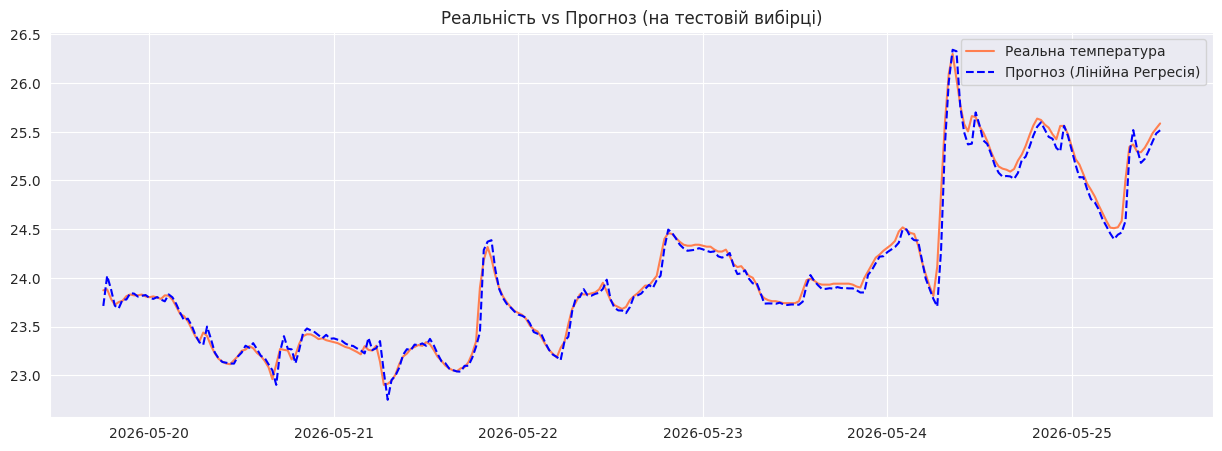

In [193]:
plt.figure(figsize=(15, 5))
# Plot the actual temperature values from the test set
plt.plot(y_test.index, y_test.values, label='Реальна температура', color='coral')
# Plot the predicted temperature values from the model
plt.plot(y_test.index, prediction, label='Прогноз (Лінійна Регресія)', color='blue', linestyle='--')
plt.title('Реальність vs Прогноз (на тестовій вибірці)')
plt.legend()
plt.show()

# Feature Importance Analysis

This section analyzes the coefficients of the Linear Regression model to understand the importance and impact of each feature on the temperature prediction. The coefficients indicate how much the target variable is expected to change when a feature changes by one unit, assuming all other features remain constant.

### Linear Regression Equation
For a linear regression model, the predicted value $\hat{y}$ is given by:
$$ \hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_k x_k $$
Where:
- $\hat{y}$ is the predicted target variable (temperature).
- $\beta_0$ is the intercept.
- $\beta_j$ are the coefficients (weights) for each feature $x_j$.
- $x_j$ are the input features.

A larger absolute value of a coefficient $|\beta_j|$ indicates a stronger influence of the feature $x_j$ on the prediction.

📊 Weights of each feature in Linear Regression:


,Feature,Weight (Coefficient)
5,temp_lag_1,1.6816
6,temp_lag_2,-0.7288
2,gas,-0.0177
4,hour_cos,-0.0146
3,hour_sin,-0.0095
7,temp_lag_48,0.0053
1,press,0.0027
0,hum,0.0017


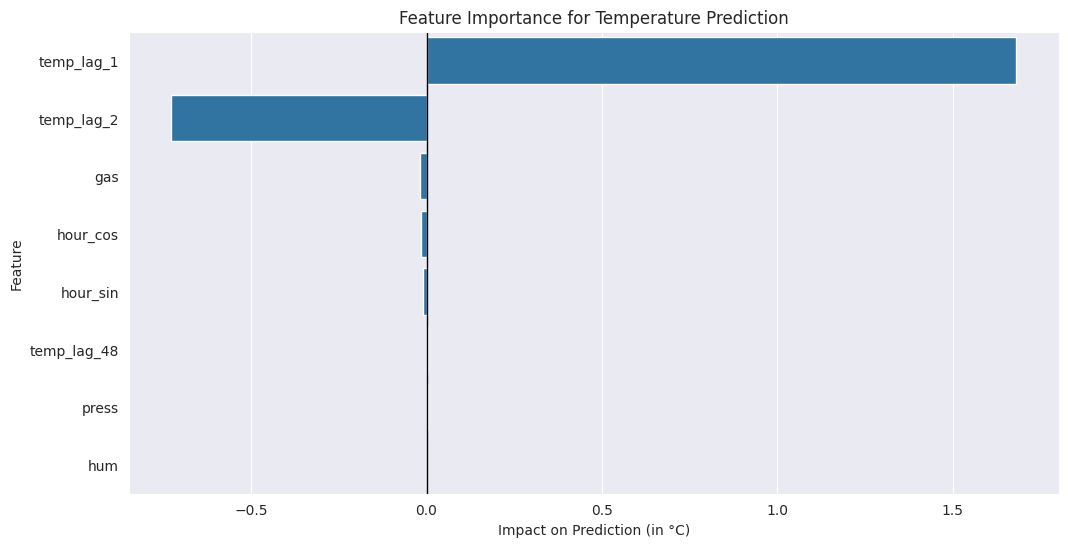

In [194]:
# 1. Create a DataFrame to store feature names and their corresponding coefficients (weights)
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Weight (Coefficient)': model.coef_
})

# 2. Add a column with the absolute value of the weights for correct sorting by importance
coefficients['Absolute Weight'] = coefficients['Weight (Coefficient)'].abs()
# Sort the DataFrame by absolute weight in descending order to show most important features first
coefficients = coefficients.sort_values(by='Absolute Weight', ascending=False)

print("📊 Weights of each feature in Linear Regression:")
# Display the sorted coefficients, rounded to 4 decimal places
display(coefficients[['Feature', 'Weight (Coefficient)']].round(4))

# 3. Create a bar plot to visualize the feature importance
plt.figure(figsize=(12, 6))
sns.barplot(
    x='Weight (Coefficient)',
    y='Feature',
    data=coefficients
)
plt.title('Feature Importance for Temperature Prediction')
plt.xlabel('Impact on Prediction (in °C)')
# Add a vertical line at x=0 to easily distinguish positive and negative impacts
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.show()

# Model Persistence

This section demonstrates how to save the trained machine learning model to a file. This allows the model to be loaded and used later for making predictions without needing to retrain it. This process is often referred to as "freezing" or "serializing" the model.

In [195]:
import joblib

# Save the trained model to a file named 'temp_predictor_30m.pkl'
joblib.dump(model, '../src/temp_predictor_30m.pkl')
print("✅ Model is saved 'temp_predictor_30m.pkl'")

✅ Модель успішно збережена у файл 'temp_predictor_30m.pkl'
